## Setup

In [1]:
import os
import sys


env_path = r"H:\conda_envs\gpu_env\Library\bin"
os.environ['PATH'] = env_path + os.pathsep + os.environ['PATH']

if os.path.exists(env_path):
    os.add_dll_directory(env_path)

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Found: {len(gpus)}")
if gpus:
    print(f"✅ Success: {gpus}")

GPUs Found: 1
✅ Success: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Organizing the data

The data within ravdess comes in folders. Each folder pertains to a certain actor. Each actor would have acted out certain emotions. We are not interested in organizing the data based on actors. We will reorganize the data based on emotions as this format will be needed down the line in our training.



In [2]:
import os
import shutil
from pathlib import Path

# 1. Define your paths
source_root = Path(r'H:\KFUPM AI\ICS504\Project\Data\audio_files')
destination_root = Path(r'H:\KFUPM AI\ICS504\Project\Data\Organized_Emotions')

# 2. Check if reorganization is already done
# If the folder exists and is not empty, we assume it's already processed
if destination_root.exists() and any(destination_root.iterdir()):
    print(f"Directory '{destination_root}' already exists and is not empty.")
    print("Skipping reorganization to avoid unnecessary processing.")
else:
    # 3. Map the 3rd number to the emotion name
    emotion_map = {
        "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
        "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
    }

    print("Starting reorganization...")

    # Ensure destination exists
    destination_root.mkdir(parents=True, exist_ok=True)

    for actor_folder in source_root.glob('Actor_*'):
        if actor_folder.is_dir():
            print(f"Processing {actor_folder.name}...")

            for wav_file in actor_folder.glob('*.wav'):
                parts = wav_file.stem.split('-')
                emotion_code = parts[2]
                emotion_name = emotion_map.get(emotion_code, "unknown")

                target_dir = destination_root / emotion_name
                target_dir.mkdir(parents=True, exist_ok=True)

                # Final check: only copy if the file doesn't already exist in the target
                target_file = target_dir / wav_file.name
                if not target_file.exists():
                    shutil.copy2(wav_file, target_file)

    print(f"\nDone! Your data is organized at: {destination_root}")

Directory 'H:\KFUPM AI\ICS504\Project\Data\Organized_Emotions' already exists and is not empty.
Skipping reorganization to avoid unnecessary processing.


### Adding TESS dataset to our collection

In [3]:
import os
import shutil

# Paths
tess_base = r'H:\KFUPM AI\ICS504\Project\Data\tess'
org_base = r'H:\KFUPM AI\ICS504\Project\Data\Organized_Emotions'

# Mapping Dictionary
emotion_map = {
    'angry': 'angry',
    'disgust': 'disgust',
    'fear': 'fearful', # TESS often uses 'fear'
    'happy': 'happy',
    'neutral': 'neutral',
    'pleasant_surprised': 'surprised',
    'pleasant_surprise': 'surprised',
    'ps': 'surprised',
    'sad': 'sad'
}

print("--- Starting TESS Data Integration v2 ---")

count = 0
# Create a list of all files to see what's happening
for root, dirs, files in os.walk(tess_base):
    for filename in files:
        if filename.endswith('.wav'):
            # Convert everything to lower to be safe
            full_search_string = (root + filename).lower()

            target_folder = None
            for key, folder in emotion_map.items():
                if key in full_search_string:
                    target_folder = folder
                    break

            if target_folder:
                source_path = os.path.join(root, filename)
                # Using a prefix to ensure we don't overwrite anything
                new_filename = f"TESS_{filename}"
                dest_dir = os.path.join(org_base, target_folder)

                # Make sure the target folder actually exists
                os.makedirs(dest_dir, exist_ok=True)

                dest_path = os.path.join(dest_dir, new_filename)

                shutil.copy(source_path, dest_path)
                count += 1
            else:
                # Debug: Print files that didn't match any emotion
                print(f"Skipped (no match): {filename}")

print(f"\n--- Success! Copied {count} files to Organized_Emotions. ---")

--- Starting TESS Data Integration v2 ---

--- Success! Copied 2806 files to Organized_Emotions. ---


### Exploring the data

First we will take a look at the RAVDESS Dataset

Audio_Speech_Actors_01-24.zip



In [4]:
### open the files
## Adjust to your location (absolute)
file_path = 'H:\KFUPM AI\ICS504\Project\Data\\audio_files\Actor_01\\03-01-01-01-01-01-01.wav'

try:
    with open(file_path, 'r') as f:
        print('file exists')
        pass
except FileNotFoundError:
    print('file missing')
    pass
print(f)
print(type(f))

file exists
<_io.TextIOWrapper name='H:\\KFUPM AI\\ICS504\\Project\\Data\\audio_files\\Actor_01\\03-01-01-01-01-01-01.wav' mode='r' encoding='cp1252'>
<class '_io.TextIOWrapper'>


In [5]:
import scipy.io.wavfile

sample_rate, data = scipy.io.wavfile.read(file_path)
print(sample_rate)
print(data)
print(type(data))
print(len(data))
print((data.shape))


48000
[0 0 0 ... 0 0 0]
<class 'numpy.ndarray'>
158558
(158558,)


X:\TEMP\ipykernel_10468\616110002.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, data = scipy.io.wavfile.read(file_path)


 Sampling Rate = 48Khz

 How often the audio is sampled per second

 Data Shape = 158558

 How many samples was collected from the clip at the sampling rate of 48Khz

 158,558/48,000 = 3.3 ==> audio file was 3.3 seconds long

3 seconds means we expect 144,000 samples per audio clip (3x48,000)

### Data Sanitization

TensorFlow has a problem with the metadata of the wav files from RAVDESS dataset. Below code rewrites the wav files to be compatible with tensor flow

In [6]:
import librosa
import soundfile as sf
import os
import numpy as np
data_path = r'H:\KFUPM AI\ICS504\Project\Data\Organized_Emotions'

print("Cleaning and standardizing files...")

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith('.wav'):
            path = os.path.join(root, file)
            try:
                # 1. Load with librosa (ignores bad headers, handles stereo -> mono)
                y, sr = librosa.load(path, sr=48000, mono=True)

                # 2. Force length to exactly 3 seconds (144,000 samples)
                target_len = 144000
                if len(y) < target_len:
                    y = np.pad(y, (0, target_len - len(y)))
                else:
                    y = y[:target_len]

                # 3. Overwrite the file with a 'Clean' version
                # soundfile writes pure PCM data without the weird metadata TF hates
                sf.write(path, y, sr, subtype='PCM_16')

            except Exception as e:
                print(f"Failed to fix {path}: {e}")

print("Sanitization complete. Your folder is now 'TensorFlow-Ready'.")

Cleaning and standardizing files...
Sanitization complete. Your folder is now 'TensorFlow-Ready'.


From the above cell we can see that the sampling rate is 48 Khz.

The audio is mono because there is no second value in (158558,)

Each value within the vector  represents the sampled at that instance (at 48 Khz)



### Dataset Splitting

Utilize keras audio dataset utility function which takes a folder name as input. The subfolder names are the class names and the files within are the data. (This step justifies the reorganizing done previously)

|| Parent Folder

----|| Class1

-----------|data1.wav

-----------|data2.wav

-----------|data3.wav

----|| Class2

-----------|data4.wav

-----------|data5.wav

-----------|data6.wav


In [7]:
import numpy as np

# Re-run this to fix the variable length issue
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=r'H:\KFUPM AI\ICS504\Project\Data\Organized_Emotions',
    batch_size=None,
    validation_split=0.2,
    seed=0,
    output_sequence_length=144000, # Fixed length (3 seconds)
    subset='both')

label_names = np.array(train_ds.class_names)


Found 5258 files belonging to 8 classes.
Using 4207 files for training.
Using 1051 files for validation.


### Creating the spectrogram dataset

Below cell defines a function to create the spectrograms. Then we use map function to create the spectrogram datasets from the original dataset we split earlier.

https://ketanhdoshi.github.io/Audio-Intro/

A Spectrogram of a signal plots its Spectrum over time and is like a ‘photograph’ of the signal. It plots Time on the x-axis and Frequency on the y-axis.

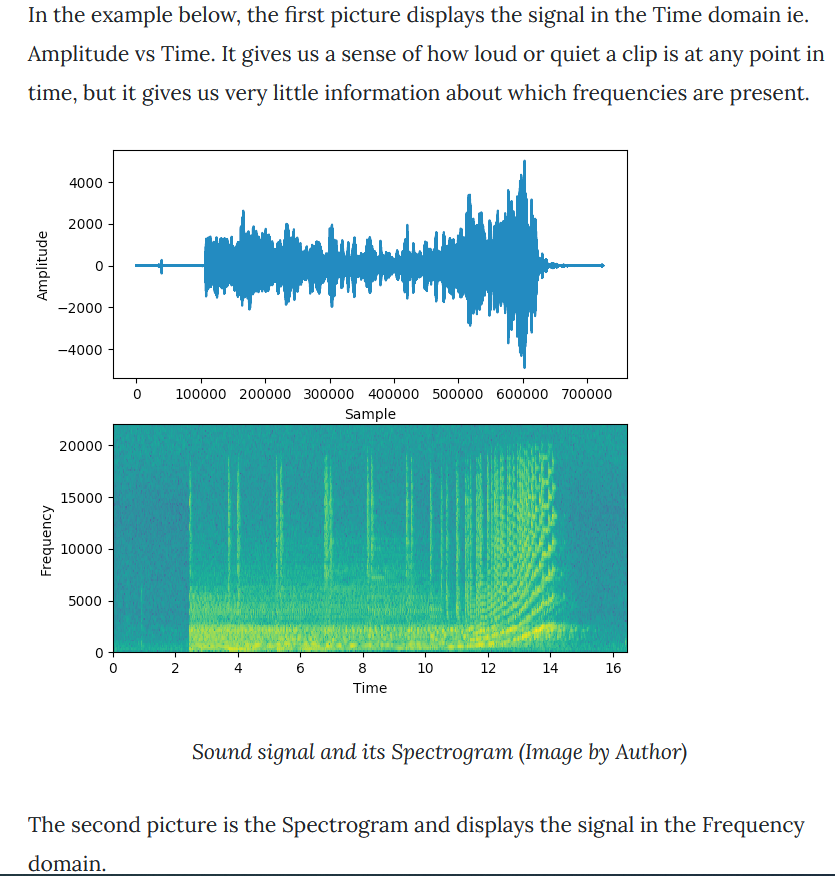


![image.png](attachment:38ada6bd-d588-4dbb-af6f-b2aae728c387.png)

## Spectrogram Vs Mel Spectrogram

https://towardsdatascience.com/audio-deep-learning-made-simple-part-2-why-mel-spectrograms-perform-better-aad889a93505/

A Mel Spectrogram makes two important changes relative to a regular Spectrogram that plots Frequency vs Time.

    It uses the Mel Scale instead of Frequency on the y-axis.
    It uses the Decibel Scale instead of Amplitude to indicate colors.

For deep learning models, we usually use this rather than a simple Spectrogram.

In summary, mel spectrograms are more attuned to lower frequencies and better mimic human perception of audio. It leads to images which are denser with information and are better for machine learning.

In [8]:
def get_mel_spectrogram_librosa(audio_tensor, label):
    def _process_audio(audio_np):
        # Handle Stereo-to-Mono conversion
        if len(audio_np.shape) > 1 and audio_np.shape[-1] > 1:
            audio_np = np.mean(audio_np, axis=-1)

        audio_np = np.squeeze(audio_np) # remove dimensions of size 1

        # Generate the Mel Spectrogram
        S = librosa.feature.melspectrogram(
            y=audio_np,
            sr=48000,
            n_fft=1024, # Number of samples in chunk thats being analyzed
            hop_length=512, # Number of samples to hop before creating the new chunk
            n_mels=80, # How many frequency bins,
            fmin=80.0,
            fmax=8000.0
        )

        log_S = librosa.power_to_db(S, ref=np.max) # convert to decibel (logarithmic scale) , easier to interpret
        return log_S.astype(np.float32)[..., np.newaxis]

    [mel_spec] = tf.py_function(_process_audio, [audio_tensor], [tf.float32])

    # Define the expected shape for the single image
    mel_spec.set_shape([80, None, 1])

    return mel_spec, label

In [9]:

def prepare_dataset(ds):
    return ds.map(get_mel_spectrogram_librosa, num_parallel_calls=tf.data.AUTOTUNE)

train_spectrogram_ds = prepare_dataset(train_ds)
val_spectrogram_ds = prepare_dataset(val_ds)

# Now it's safe to batch!
train_spectrogram_ds = train_spectrogram_ds.batch(64).cache().prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_ds.map(get_mel_spectrogram_librosa).batch(64).prefetch(tf.data.AUTOTUNE)


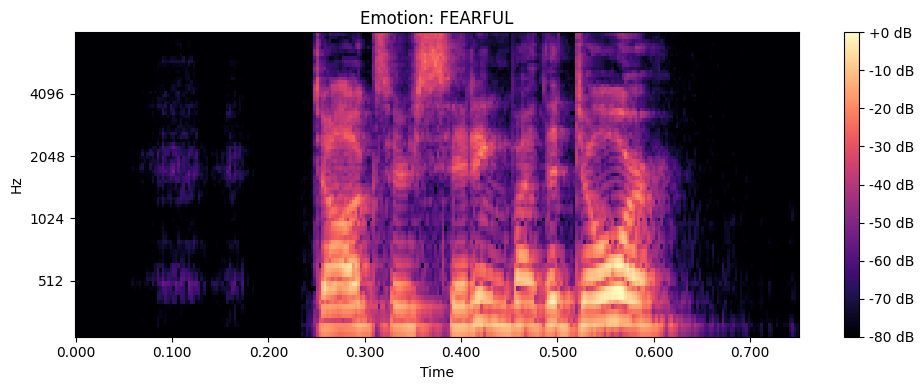

Final Spectrogram Shape: (80, 282, 1)


In [10]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

# 1. Grab one batch from the transformed dataset
for spec_batch, label_batch in train_spectrogram_ds.take(1):

    # Extract the first sample and label
    # Current shape: (Mel_Bins, Time, 1) or (Time, Mel_Bins, 1)
    # Most Librosa-style transforms result in (80, Time, 1)
    single_spec = spec_batch[0].numpy()
    single_label = label_batch[0].numpy()

    # Remove the channel dimension (the '1' at the end)
    # Resulting shape: (80, Time)
    plot_data = np.squeeze(single_spec)

    plt.figure(figsize=(10, 4))

    # Use librosa's specialized display tool
    # 'x_axis' and 'y_axis' parameters add the time/mel labels for you
    img = librosa.display.specshow(
        plot_data,
        sr=48000,
        hop_length=128,
        x_axis='time',
        y_axis='mel',
        fmin=80.0,
        fmax=8000.0,
        cmap='magma'
    )

    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f"Emotion: {label_names[single_label].upper()}")
    plt.tight_layout()
    plt.show()

    print(f"Final Spectrogram Shape: {single_spec.shape}")
    break # Only need one batch

# Model Training

## Model Architecture

In [11]:
from tensorflow.keras import layers, models

# The input shape is (Time, Frequencies, Channels)
# We exclude the 'None' (batch size)
input_shape = (1124, 80, 1)
num_labels = len(label_names)

norm_layer = layers.Normalization()
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))


for example_spec, example_label in train_spectrogram_ds.take(1):
    input_shape = example_spec.shape[1:] # This gets (Time, 80, 1)
    print(f"Corrected Input Shape: {input_shape}")


model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Resizing(64, 64),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.30),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.35),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_labels)
])

model.summary()

Corrected Input Shape: (80, 282, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing (Resizing)         (None, 64, 64, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxP

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

# It's highly recommended to use EarlyStopping so you don't waste time
# if the model stops improving.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

scheduler =  tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

checkpoint = tf.keras.callbacks.ModelCheckpoint(
        "best_melspec_cnn.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=50, # The early stopping will likely cut this shorter
    callbacks=[early_stopping , scheduler , checkpoint],
)

In [13]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Collect all true labels from the validation dataset
print("Extracting true labels...")
y_true = []
for _, labels in val_spectrogram_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# 2. Generate predictions
print("Generating predictions...")
y_pred_probs = model.predict(val_spectrogram_ds)

# 3. Convert probabilities to class indices
# Since your loss is SparseCategoricalCrossentropy(from_logits=True),
# we take the argmax of the output logits/probs
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Generate and print the report
# label_names was defined in your code as np.array(train_ds.class_names)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=label_names))

Extracting true labels...
Generating predictions...
17/17 [==============================] - 5s 317ms/step

--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.89      0.83      0.86       157
        calm       0.49      0.69      0.58        68
     disgust       0.93      0.87      0.90       115
     fearful       0.63      0.93      0.75       159
       happy       0.94      0.63      0.76       164
     neutral       0.97      0.69      0.81       123
         sad       0.63      0.66      0.64       140
   surprised       0.89      0.87      0.88       125

    accuracy                           0.78      1051
   macro avg       0.80      0.77      0.77      1051
weighted avg       0.81      0.78      0.78      1051



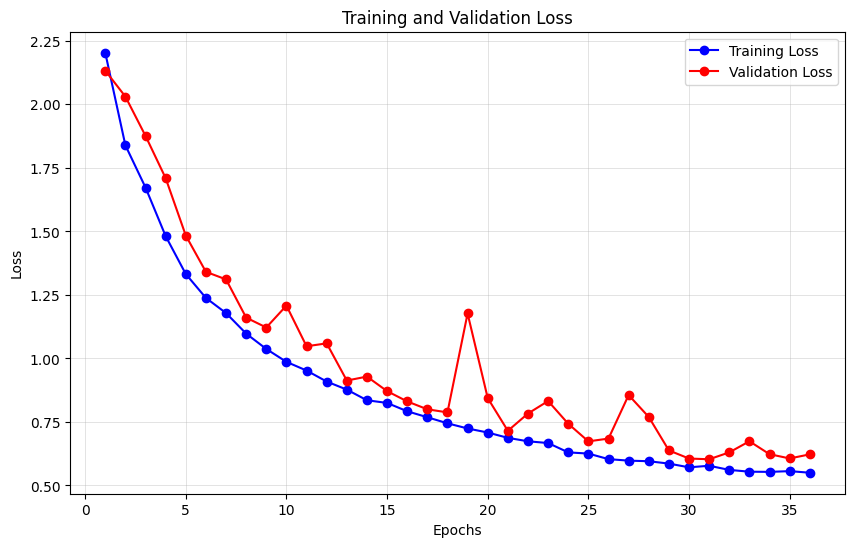

In [14]:
import matplotlib.pyplot as plt

# Assuming 'history' is the variable returned by model.fit()
def plot_loss(history):
    plt.figure(figsize=(10, 6))

    # Extract loss values
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(train_loss) + 1)

    # Plotting
    plt.plot(epochs, train_loss, 'bo-', label='Training Loss') # 'bo-' = blue dots/line
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss') # 'ro-' = red dots/line

    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_loss(history)

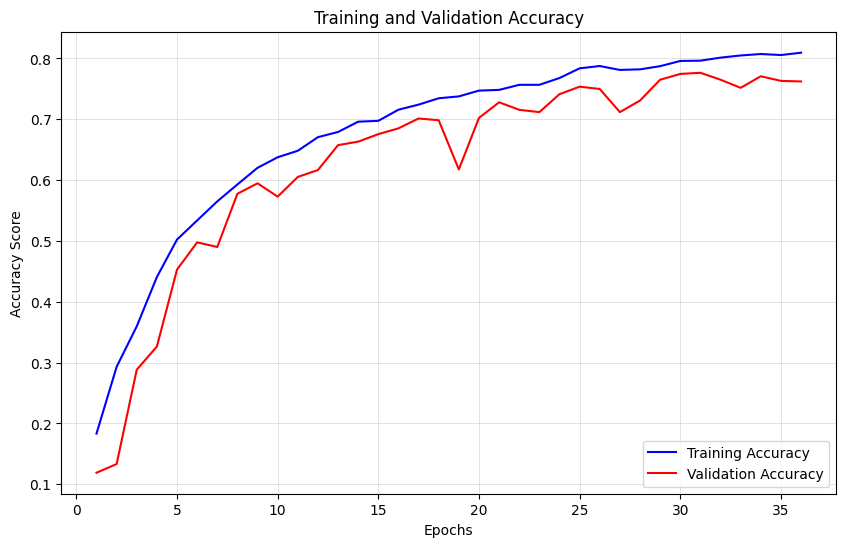

In [15]:

def plot_accuracy(history):
    plt.figure(figsize=(10, 6))
    
    # Extract accuracy values
    # Note: Use 'acc' and 'val_acc' for older versions of Keras
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(train_acc) + 1)

    # Plotting
    plt.plot(epochs, train_acc, 'b-', label='Training Accuracy') 
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy') 
    
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True)
    
    plt.savefig('accuracy_plot.png')
    
plot_accuracy(history)

In [16]:
print(f"Model stopped at epoch: {early_stopping.stopped_epoch}")

test_loss, test_acc = model.evaluate(val_spectrogram_ds, verbose=2)
print('Accuracy for ADAM')
print(f'\nTest accuracy: {test_acc}')

compilers_results ={'adam':test_acc }

Model stopped at epoch: 35
17/17 - 5s - loss: 0.6030 - accuracy: 0.7764 - 5s/epoch - 312ms/step
Accuracy for ADAM

Test accuracy: 0.7764034271240234


## VGG

In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# 1. Update the input shape to match your ACTUAL Mel Spectrograms
# Based on your previous run, it's something like (80, 282, 1) or (80, 1125, 1)
# Let's pull it from your input_shape variable
mel_height = 80
mel_width = input_shape[1] # Use the width from your dataset

model_vgg = models.Sequential([
    layers.Input(shape=(mel_height, mel_width, 1)),

    # OPTIONAL: Use Resizing only if the image is too large for your GPU
    # but keep it at a decent resolution (e.g., 128x128 or 224x224)
    # layers.Resizing(128, 256),

    # Convert 1 channel (Grayscale) to 3 channels (RGB) for VGG16
    layers.Conv2D(3, (3, 3), padding='same'),

    # The VGG16 Base (Pre-trained on ImageNet)
    VGG16(weights='imagenet', include_top=False, input_shape=(None, None, 3)),

    # Global Average Pooling is better than Flatten for audio
    layers.GlobalAveragePooling2D(),

    # Final Classification Layers
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels, activation='softmax')
])

# --- FINE-TUNING STEP ---
# Initially, we freeze the whole VGG base
model_vgg.layers[1].trainable = False

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), # Low learning rate for transfer learning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 80, 282, 3)        30        
                                                                 
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d_1   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 512)               262656    
                                                                 
 dropout_4 (Dropout)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 8)                 4104      
                                                      

In [18]:
# Unfreeze the VGG16 base
model_vgg.layers[1].trainable = True

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Cut learning rate in half when progress stalls
    patience=2,      # Wait only 2 epochs before slowing down
    min_lr=1e-6,     # Don't let it get slower than this
    verbose=1
)

# Re-compile with an EXTREMELY low learning rate
# You don't want to "break" the pre-trained weights, just nudge them
model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_finetune = model_vgg.fit(train_spectrogram_ds, validation_data=val_spectrogram_ds, epochs=50, callbacks=[early_stopping])

Epoch 1/50
66/66 [==============================] - 68s 736ms/step - loss: 1.8387 - accuracy: 0.3166 - val_loss: 1.0979 - val_accuracy: 0.6461
Epoch 2/50
66/66 [==============================] - 31s 473ms/step - loss: 1.0648 - accuracy: 0.6059 - val_loss: 0.7673 - val_accuracy: 0.7260
Epoch 3/50
66/66 [==============================] - 30s 451ms/step - loss: 0.8181 - accuracy: 0.6936 - val_loss: 0.6835 - val_accuracy: 0.7574
Epoch 4/50
66/66 [==============================] - 30s 450ms/step - loss: 0.7113 - accuracy: 0.7397 - val_loss: 0.6536 - val_accuracy: 0.7707
Epoch 5/50
66/66 [==============================] - 30s 449ms/step - loss: 0.6333 - accuracy: 0.7642 - val_loss: 0.5832 - val_accuracy: 0.7926
Epoch 6/50
66/66 [==============================] - 31s 476ms/step - loss: 0.5648 - accuracy: 0.7944 - val_loss: 0.5385 - val_accuracy: 0.7983
Epoch 7/50
66/66 [==============================] - 32s 489ms/step - loss: 0.5144 - accuracy: 0.8120 - val_loss: 0.4960 - val_accuracy: 0.8164

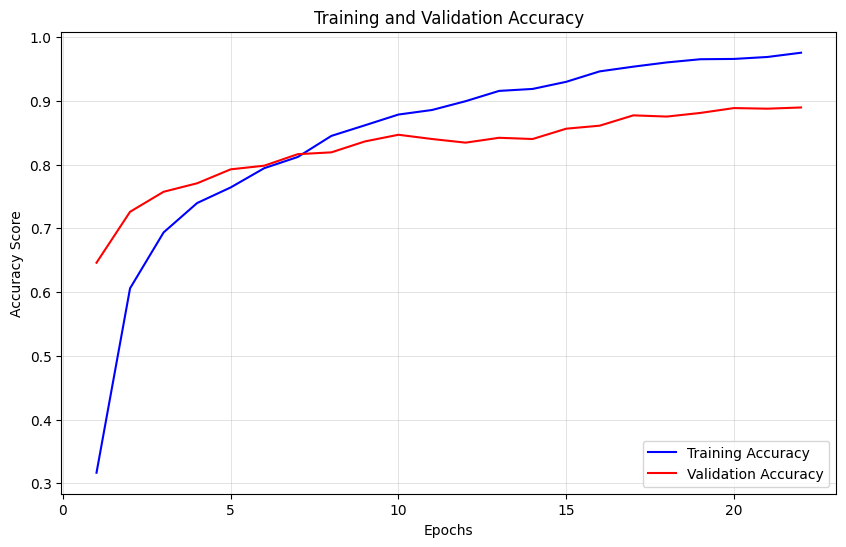

In [19]:

def plot_accuracy(history):
    plt.figure(figsize=(10, 6))

    # Extract accuracy values
    # Note: Use 'acc' and 'val_acc' for older versions of Keras
    train_acc = history_finetune.history['accuracy']
    val_acc = history_finetune.history['val_accuracy']
    epochs = range(1, len(train_acc) + 1)

    # Plotting
    plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')

    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.savefig('accuracy_plot.png')

plot_accuracy(history)

In [20]:
model_vgg.save('my_emotion_model.keras')

In [21]:
model_vgg = tf.keras.models.load_model("H:\KFUPM AI\ICS504\Project\ics504project\my_emotion_model.keras")
label_names = np.array(train_ds.class_names)


17/17 [==============================] - 6s 359ms/step


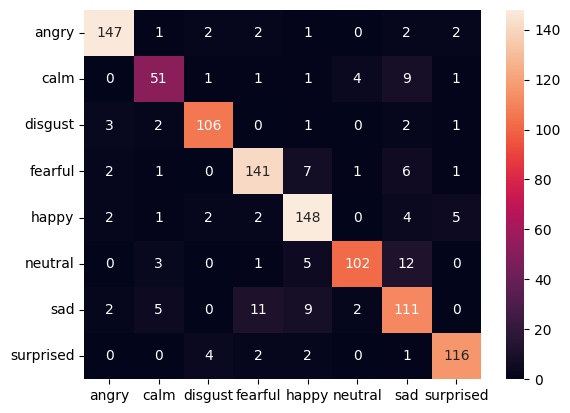

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions
y_pred = model_vgg.predict(val_spectrogram_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels from the dataset
y_true = np.concatenate([y for x, y in val_spectrogram_ds], axis=0)

cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names , yticklabels=label_names)
plt.show()

# VGG2

In [23]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# -----------------------------
# Input shape
# -----------------------------
mel_height = 80
mel_width = input_shape[1]

# -----------------------------
# Build VGG16 transfer-learning model
# -----------------------------
inputs = layers.Input(shape=(mel_height, mel_width, 1), name="mel_input")

# Convert grayscale mel spectrogram to 3 channels for VGG16
x = layers.Conv2D(3, (3, 3), padding="same", name="gray_to_rgb")(inputs)

# VGG16 base
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(None, None, 3)
)

# Stage 1: freeze VGG16 base
base_model.trainable = False

x = base_model(x)

x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)

x = layers.Dense(512, activation="relu", name="classifier_dense")(x)
x = layers.Dropout(0.5, name="classifier_dropout")(x)

outputs = layers.Dense(num_labels, activation="softmax", name="emotion_output")(x)

model_vgg = models.Model(inputs=inputs, outputs=outputs, name="vgg16_melspec_emotion")

# -----------------------------
# Compile Stage 1
# -----------------------------
model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_vgg.summary()

Model: "vgg16_melspec_emotion"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mel_input (InputLayer)      [(None, 80, 282, 1)]      0         
                                                                 
 gray_to_rgb (Conv2D)        (None, 80, 282, 3)        30        
                                                                 
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_avg_pool (GlobalAver  (None, 512)              0         
 agePooling2D)                                                   
                                                                 
 classifier_dense (Dense)    (None, 512)               262656    
                                                                 
 classifier_dropout (Dropout  (None, 512)              0         
 )                                           

## Train stage 1

In [24]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_vgg16_melspec_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_stage1 = model_vgg.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=30,
    callbacks=[early_stopping, lr_scheduler, checkpoint_cb]
)

Epoch 1/30
66/66 [==============================] - ETA: 0s - loss: 2.6002 - accuracy: 0.1937
Epoch 1: val_accuracy improved from -inf to 0.44529, saving model to best_vgg16_melspec_model.h5
66/66 [==============================] - 23s 335ms/step - loss: 2.6002 - accuracy: 0.1937 - val_loss: 1.5472 - val_accuracy: 0.4453 - lr: 1.0000e-04
Epoch 2/30
66/66 [==============================] - ETA: 0s - loss: 1.9214 - accuracy: 0.3183
Epoch 2: val_accuracy improved from 0.44529 to 0.55756, saving model to best_vgg16_melspec_model.h5
66/66 [==============================] - 22s 329ms/step - loss: 1.9214 - accuracy: 0.3183 - val_loss: 1.3093 - val_accuracy: 0.5576 - lr: 1.0000e-04
Epoch 3/30
66/66 [==============================] - ETA: 0s - loss: 1.5351 - accuracy: 0.4340
Epoch 3: val_accuracy improved from 0.55756 to 0.61465, saving model to best_vgg16_melspec_model.h5
66/66 [==============================] - 22s 332ms/step - loss: 1.5351 - accuracy: 0.4340 - val_loss: 1.1863 - val_accuracy

## Fine Tune Stage 2

In [ ]:
# -----------------------------
# Stage 2: Fine-tune top VGG16 layers
# -----------------------------
base_model.trainable = True

# Freeze most VGG16 layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only the last few layers
for layer in base_model.layers[-8:]:
    layer.trainable = True
    print("Unfrozen:", layer.name)

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Trainable layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

history_finetune = model_vgg.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=50,
    callbacks=[early_stopping, lr_scheduler, checkpoint_cb]
)

Unfrozen: block4_conv1
Unfrozen: block4_conv2
Unfrozen: block4_conv3
Unfrozen: block4_pool
Unfrozen: block5_conv1
Unfrozen: block5_conv2
Unfrozen: block5_conv3
Unfrozen: block5_pool
Trainable layers:
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool
Epoch 1/50
66/66 [==============================] - ETA: 0s - loss: 0.6051 - accuracy: 0.7766
Epoch 1: val_accuracy improved from 0.74976 to 0.77165, saving model to best_vgg16_melspec_model.h5
66/66 [==============================] - 26s 381ms/step - loss: 0.6051 - accuracy: 0.7766 - val_loss: 0.6062 - val_accuracy: 0.7716 - lr: 1.0000e-05
Epoch 2/50
66/66 [==============================] - ETA: 0s - loss: 0.4735 - accuracy: 0.8246
Epoch 2: val_accuracy improved from 0.77165 to 0.79068, saving model to best_vgg16_melspec_model.h5
66/66 [==============================] - 25s 374ms/step - loss: 0.4735 - accuracy: 0.8246 - val_loss: 0.5509 - val_accuracy: 0.7907 - lr: 1.0000e-05
Epoch 3/50
6

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Collect all true labels from the validation dataset
print("Extracting true labels...")
y_true = []
for _, labels in val_spectrogram_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# 2. Generate predictions
print("Generating predictions...")
y_pred_probs = model_vgg.predict(val_spectrogram_ds)

# 3. Convert probabilities to class indices
# Since your loss is SparseCategoricalCrossentropy(from_logits=True),
# we take the argmax of the output logits/probs
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Generate and print the report
# label_names was defined in your code as np.array(train_ds.class_names)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=label_names))

In [ ]:
def plot_accuracy(history):
    plt.figure(figsize=(10, 6))

    # Extract accuracy values
    # Note: Use 'acc' and 'val_acc' for older versions of Keras
    train_acc = history_finetune.history['accuracy']
    val_acc = history_finetune.history['val_accuracy']
    epochs = range(1, len(train_acc) + 1)

    # Plotting
    plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')

    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.savefig('accuracy_plot.png')

plot_accuracy(history)

# Training Model on Arabic data set only (EYASE)


## Preparing the data

In [ ]:
import os
import shutil

source_root = r"H:\KFUPM AI\ICS504\Project\Data\EYASE\EYASE"
target_root = r"H:\KFUPM AI\ICS504\Project\Data\EYASE\EYASE_by_emotion"

emotions = ["hap", "sad", "neu", "ang"]

for emotion in emotions:
    os.makedirs(os.path.join(target_root, emotion), exist_ok=True)

for speaker_folder in os.listdir(source_root):
    speaker_path = os.path.join(source_root, speaker_folder)

    if not os.path.isdir(speaker_path):
        continue

    for filename in os.listdir(speaker_path):
        if not filename.lower().endswith(".wav"):
            continue

        filename_lower = filename.lower()

        for emotion in emotions:
            if emotion in filename_lower:
                source_file = os.path.join(speaker_path, filename)

                new_filename = f"{speaker_folder}_{filename}"
                target_file = os.path.join(target_root, emotion, new_filename)

                shutil.copy2(source_file, target_file)
                break

print("Done. Files copied by emotion.")

## Creating Mel Spectrograms

In [ ]:
import librosa
import soundfile as sf
import os
import numpy as np
data_path = r'H:\KFUPM AI\ICS504\Project\Data\EYASE\EYASE_by_emotion'

print("Cleaning and standardizing files...")

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith('.wav'):
            path = os.path.join(root, file)
            try:
                # 1. Load with librosa (ignores bad headers, handles stereo -> mono)
                y, sr = librosa.load(path, sr=48000, mono=True)

                # 2. Force length to exactly 3 seconds (144,000 samples)
                target_len = 144000
                if len(y) < target_len:
                    y = np.pad(y, (0, target_len - len(y)))
                else:
                    y = y[:target_len]

                # 3. Overwrite the file with a 'Clean' version
                # soundfile writes pure PCM data without the weird metadata TF hates
                sf.write(path, y, sr, subtype='PCM_16')

            except Exception as e:
                print(f"Failed to fix {path}: {e}")

print("Sanitization complete. Your folder is now 'TensorFlow-Ready'.")

In [ ]:
import numpy as np

# Re-run this to fix the variable length issue
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=r'H:\KFUPM AI\ICS504\Project\Data\EYASE\EYASE_by_emotion',
    batch_size=None,
    validation_split=0.2,
    seed=0,
    output_sequence_length=144000, # Fixed length (3 seconds)
    subset='both')

label_names = np.array(train_ds.class_names)
print(label_names)

In [ ]:
def get_mel_spectrogram_librosa(audio_tensor, label):
    def _process_audio(audio_np):
        # Handle Stereo-to-Mono conversion
        if len(audio_np.shape) > 1 and audio_np.shape[-1] > 1:
            audio_np = np.mean(audio_np, axis=-1)

        audio_np = np.squeeze(audio_np)  # remove dimensions of size 1

        # Generate the Mel Spectrogram
        S = librosa.feature.melspectrogram(
            y=audio_np,
            sr=48000,
            n_fft=1024,  # Number of samples in chunk thats being analyzed
            hop_length=512,  # Number of samples to hop before creating the new chunk
            n_mels=80,  # How many frequency bins,
            fmin=80.0,
            fmax=8000.0
        )

        log_S = librosa.power_to_db(S, ref=np.max)  # convert to decibel (logarithmic scale) , easier to interpret
        return log_S.astype(np.float32)[..., np.newaxis]

    [mel_spec] = tf.py_function(_process_audio, [audio_tensor], [tf.float32])

    # Define the expected shape for the single image
    mel_spec.set_shape([80, None, 1])

    return mel_spec, label


def prepare_dataset(ds):
    return ds.map(get_mel_spectrogram_librosa, num_parallel_calls=tf.data.AUTOTUNE)


train_spectrogram_ds = prepare_dataset(train_ds)
val_spectrogram_ds = prepare_dataset(val_ds)

# Now it's safe to batch!
train_spectrogram_ds = train_spectrogram_ds.batch(64).cache().prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_ds.map(get_mel_spectrogram_librosa).batch(64).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# 1. Update the input shape to match your ACTUAL Mel Spectrograms
# Based on your previous run, it's something like (80, 282, 1) or (80, 1125, 1)
# Let's pull it from your input_shape variable
mel_height = 80
input_shape = (1124, 80, 1)
num_labels = len(label_names)
mel_width = input_shape[1] # Use the width from your dataset

model_vgg = models.Sequential([
    layers.Input(shape=(mel_height, mel_width, 1)),

    # OPTIONAL: Use Resizing only if the image is too large for your GPU
    # but keep it at a decent resolution (e.g., 128x128 or 224x224)
    # layers.Resizing(128, 256),

    # Convert 1 channel (Grayscale) to 3 channels (RGB) for VGG16
    layers.Conv2D(3, (3, 3), padding='same'),

    # The VGG16 Base (Pre-trained on ImageNet)
    VGG16(weights='imagenet', include_top=False, input_shape=(None, None, 3)),

    # Global Average Pooling is better than Flatten for audio
    layers.GlobalAveragePooling2D(),

    # Final Classification Layers
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels, activation='softmax')
])

# --- FINE-TUNING STEP ---
# Initially, we freeze the whole VGG base
model_vgg.layers[1].trainable = False

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), # Low learning rate for transfer learning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model_vgg.summary()

In [ ]:
# Unfreeze the VGG16 base
model_vgg.layers[1].trainable = True

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Cut learning rate in half when progress stalls
    patience=2,      # Wait only 2 epochs before slowing down
    min_lr=1e-6,     # Don't let it get slower than this
    verbose=1
)

# Re-compile with an EXTREMELY low learning rate
# You don't want to "break" the pre-trained weights, just nudge them
model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_finetune = model_vgg.fit(train_spectrogram_ds, validation_data=val_spectrogram_ds, epochs=50, callbacks=[early_stopping])

### Validation Accuracy Plot

In [ ]:
def plot_accuracy(history):
    plt.figure(figsize=(10, 6))

    # Extract accuracy values
    # Note: Use 'acc' and 'val_acc' for older versions of Keras
    train_acc = history_finetune.history['accuracy']
    val_acc = history_finetune.history['val_accuracy']
    epochs = range(1, len(train_acc) + 1)

    # Plotting
    plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')

    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.savefig('accuracy_plot.png')
plot_accuracy(history_finetune)


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Collect all true labels from the validation dataset
print("Extracting true labels...")
y_true = []
for _, labels in val_spectrogram_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# 2. Generate predictions
print("Generating predictions...")
y_pred_probs = model_vgg.predict(val_spectrogram_ds)

# 3. Convert probabilities to class indices
# Since your loss is SparseCategoricalCrossentropy(from_logits=True),
# we take the argmax of the output logits/probs
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Generate and print the report
# label_names was defined in your code as np.array(train_ds.class_names)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=label_names))

### Confusion Matrix

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for x_batch, y_batch in val_spectrogram_ds:
    preds = model_vgg.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_names
))

### Showcasing 10 random samples

In [ ]:
import random
import matplotlib.pyplot as plt
import IPython.display as ipd
import tensorflow as tf
import numpy as np

all_x = []
all_y = []
all_audio = []

for (x_batch, y_batch), (audio_batch, _) in zip(val_spectrogram_ds, val_ds.batch(64)):
    all_x.append(x_batch)
    all_y.append(y_batch)
    all_audio.append(audio_batch)

all_x = tf.concat(all_x, axis=0)
all_y = tf.concat(all_y, axis=0)
all_audio = tf.concat(all_audio, axis=0)

idxs = random.sample(range(len(all_y)), 10)

for idx in idxs:
    x = all_x[idx:idx+1]
    true_label = label_names[all_y[idx].numpy()]

    preds = model_vgg.predict(x, verbose=0)
    pred_label = label_names[np.argmax(preds)]
    conf = np.max(preds)

    print("=" * 50)
    print(f"True: {true_label}")
    print(f"Pred: {pred_label}")
    print(f"Confidence: {conf:.2f}")

    display(ipd.Audio(tf.squeeze(all_audio[idx]).numpy(), rate=48000))

    plt.figure(figsize=(5, 3))
    plt.imshow(tf.squeeze(all_x[idx]).numpy(), aspect="auto", origin="lower")
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.colorbar()
    plt.show()